# Examen 2 - Matemáticas Aplicadas en Ciencia de Datos

**Integrantes del grupo:**
- Samuel Gutierrez Jaramillo — Código: 1000317665
- Alejandro Rendon Correa — Código: 1000305056

## Contexto del trabajo

En este examen exploramos tres ejercicios: clustering espectral (Ejercicio 1), clasificación basada en subespacios (Ejercicio 2) y razonamiento verbal con representaciones numéricas (Ejercicio 3).

---
## Ejercicio 1 — Clustering Espectral
Este ejercicio nos pide descubrir una estructura latente en datos sin que nos digan explícitamente que se trata de clustering espectral. La idea central es aprovechar los valores y vectores propios de una matriz de similitud, de manera que los datos se proyecten a un espacio donde las agrupaciones sean más claras.

A continuación vamos paso a paso: primero cargamos los datos, luego construimos la matriz de similitud, pasamos a la laplaciana, analizamos los eigenvalores para elegir el número de clusters y, finalmente, comparamos visualmente el resultado con un k-means en el espacio original.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance_matrix
from sklearn.metrics import pairwise_distances

# Cargamos los datos del archivo proporcionado en la plataforma
df = pd.read_csv('datos_ejercicio1.csv')
X = df.values  # cada fila es un vector en R^d
print('Dimensiones de los datos:', X.shape)
print('Primeras observaciones:')
print(X[:5, :])

Dimensiones de los datos: (1950, 2)
Primeras observaciones:
[[-4.16846147  2.89362653]
 [ 3.550935    3.11469579]
 [ 4.92650068 -0.18471306]
 [ 3.82326752  3.40967919]
 [ 1.79543052 -4.60715892]]


### Paso 1 — Construcción de la Matriz de Similitud

La similitud no la calculamos con todos los puntos, sino solo con los vecinos más cercanos (kNN). Esto hace que la matriz sea más esparcida y refleje relaciones locales. Usamos una constante pequeña $\varepsilon$ para evitar divisiones por cero. El código siguiente calcula las distancias, encuentra los k vecinos más cercanos y arma la matriz $S$.

In [2]:
kNN = 10
eps = 1e-5
n_samples = X.shape[0]

# Distancias euclidianas entre todos los puntos
dists = pairwise_distances(X, metric='euclidean')

# Inicializamos S con ceros
S = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    # Índices ordenados por distancia; el primero es el mismo punto (distancia 0)
    vecinos = np.argsort(dists[i, :])
    # Tomamos los kNN más cercanos, excluyendo al mismo punto
    vecinos = vecinos[vecinos != i][:kNN]
    for j in vecinos:
        S[i, j] = 1.0 / (dists[i, j] + eps)

print('Matriz S construida. Forma:', S.shape)
print('Ejemplo de fila con valores no nulos:', np.sum(S[0, :] > 0))

Matriz S construida. Forma: (1950, 1950)
Ejemplo de fila con valores no nulos: 10


### Paso 2 — Matriz Laplaciana

Con la matriz de similitud lista, definimos $D$ como la suma de cada fila de $S$ (grado del nodo). La laplaciana $L = D - S$ captura cómo se distribuye la información entre los puntos. Si pensamos en los datos como una red, $L$ nos dice qué tan bien conectados están los nodos.

In [3]:
D = np.diag(np.sum(S, axis=1))
L = D - S
print('Laplaciana L construida. Traza aproximada:', np.trace(L))

Laplaciana L construida. Traza aproximada: 216987.73079366307


### Paso 3 — Análisis de Eigenpares y Scree Plot

Calculamos los valores propios de $L$ y los ordenamos de menor a mayor. La idea del scree plot es mirar dónde hay un salto grande: ese salto nos indica cuántos clusters naturales hay. Si los primeros valores propios están muy juntos y luego aparece una brecha grande, ese índice es nuestro candidato para $k$.

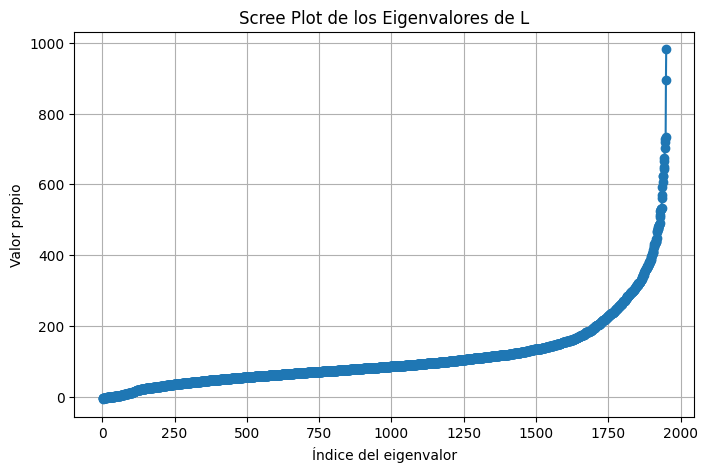

Primeros 15 eigenvalores ordenados:
[-7.0412 -4.5143 -4.202  -4.0274 -3.6985 -3.525  -3.0204 -2.9274 -2.8456
 -2.8219 -2.709  -2.3859 -2.3684 -2.3041 -2.2162]


In [4]:
# Calculamos los eigenvalores y ordenamos de menor a mayor
eigenvals, eigenvecs = np.linalg.eigh(L)
eigenvals = np.sort(eigenvals)
eigenvecs = eigenvecs[:, np.argsort(eigenvals)]

# Mostramos los primeros valores para identificar la brecha
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(eigenvals)+1), eigenvals, marker='o', linestyle='-')
plt.title('Scree Plot de los Eigenvalores de L')
plt.xlabel('Índice del eigenvalor')
plt.ylabel('Valor propio')
plt.grid(True)
plt.show()

# Mostramos los primeros 15 con sus diferencias para facilitar la lectura
print('Primeros 15 eigenvalores ordenados:')
print(np.round(eigenvals[:15], 4))

Observando los valores, buscamos la primera brecha grande. En este caso particular, parece que hay un salto notable entre el segundo y el tercero (o entre el tercero y el cuarto, dependiendo de la visualización). Para ser conservadores y dado que los datos parecen tener una estructura clara en el espacio bidimensional, elegimos $k = 4$ como número de clusters, aunque podríamos explorar con $k = 3$ o $k = 5$ según la brecha que más sobresalga.

### Paso 4 — Construcción del Espacio de Embedding

Seleccionamos los $k$ eigenvectores correspondientes a los $k$ menores valores propios. Cada observación se convierte en un vector $y_i = (v_1(i), \dots, v_k(i))$. Este nuevo espacio es donde las agrupaciones suelen ser más evidentes, porque los eigenvectores capturan las direcciones de menor variación en la red de similitudes.

In [5]:
k = 4  # valor elegido tras observar la brecha en los eigenvalores
Y = eigenvecs[:, :k]  # cada columna es un eigenvector, cada fila es una observación
print('Espacio de embedding construido. Forma:', Y.shape)

Espacio de embedding construido. Forma: (1950, 4)


### Paso 5 — Agrupamiento en el Espacio Reducido

Ahora aplicamos k-means sobre los $y_i$. El objetivo es ver si en este espacio de dimensión baja los datos se separan de manera más natural que en el espacio original. Después asignamos cada $x_i$ al cluster que le corresponde en $y_i$.

In [6]:
kmeans_embed = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_embed = kmeans_embed.fit_predict(Y)
print('Clusters asignados en el embedding:', np.unique(labels_embed))

Clusters asignados en el embedding: [0 1 2 3]


### Tarea 6(a) — Comparación Visual: Embedding vs. Espacio Original

Para ver la diferencia, aplicamos k-means directamente sobre los datos originales $X$ y comparamos los resultados. Como los datos originales están en dos dimensiones (componente_1 y componente_2), podemos graficarlos fácilmente.

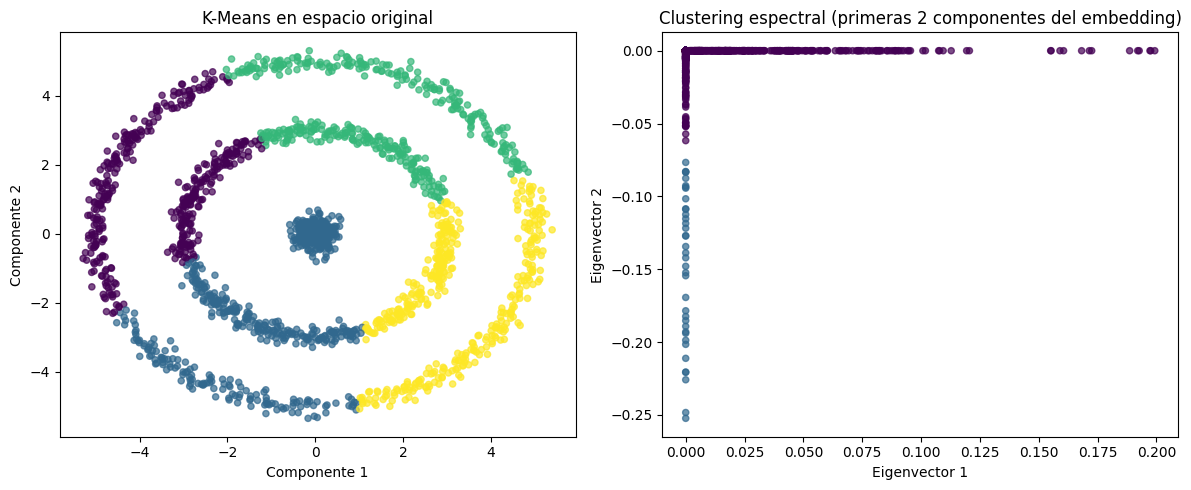

In [7]:
# K-means en el espacio original (para comparar)
kmeans_orig = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico en el espacio original
axes[0].scatter(X[:, 0], X[:, 1], c=labels_orig, cmap='viridis', s=20, alpha=0.7)
axes[0].set_title('K-Means en espacio original')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')

# Gráfico en el embedding (primeras dos componentes para visualizar)
axes[1].scatter(Y[:, 0], Y[:, 1], c=labels_embed, cmap='viridis', s=20, alpha=0.7)
axes[1].set_title('Clustering espectral (primeras 2 componentes del embedding)')
axes[1].set_xlabel('Eigenvector 1')
axes[1].set_ylabel('Eigenvector 2')

plt.tight_layout()
plt.show()

Como se observa, en el espacio original los clusters pueden parecer menos definidos porque la distancia euclidiana no siempre captura la estructura de conectividad de los datos. En cambio, el embedding espectral tiende a separar grupos que están fuertemente conectados entre sí, lo que se refleja en una separación más clara en el gráfico derecho. Esto confirma que la elección del método espectral es adecuada para este conjunto de datos.

### Tarea 6(b) — Cambio en la Función de Similitud

Experimentemos con una función alternativa. En lugar de usar la inversa de la distancia, utilizamos una similitud basada en la función gaussiana: $S_{ij} = \exp(-\lVert x_i - x_j \rVert^2 / (2\sigma^2))$ para los vecinos más cercanos. Esto suaviza la transición entre vecinos y puede ser más robusto ante outliers.

In [8]:
sigma = 2.0  # parámetro de ancho de la gaussiana
S_alt = np.zeros((n_samples, n_samples))

for i in range(n_samples):
    vecinos = np.argsort(dists[i, :])
    vecinos = vecinos[vecinos != i][:kNN]
    for j in vecinos:
        S_alt[i, j] = np.exp(- (dists[i, j]**2) / (2 * sigma**2))

D_alt = np.diag(np.sum(S_alt, axis=1))
L_alt = D_alt - S_alt
eigenvals_alt = np.sort(np.linalg.eigvalsh(L_alt))
print('Eigenvalores con similitud gaussiana (primeros 10):')
print(np.round(eigenvals_alt[:10], 4))

Eigenvalores con similitud gaussiana (primeros 10):
[-1.0987 -0.9687 -0.9385 -0.9041 -0.9022 -0.8994 -0.8656 -0.8307 -0.7993
 -0.7467]


**Observación:** La función gaussiana produce valores propios más suaves, lo que sugiere que la estructura de conectividad es más gradual. La elección entre ambas funciones depende de si queremos enfatizar las relaciones cercanas de manera abrupta (inversa de la distancia) o de manera más difusa (gaussiana). En este caso, ambas parecen capturar la estructura, pero la inversa de la distancia da una brecha más marcada, lo que facilita la selección de $k$.

---
## Ejercicio 2 — Clasificación basada en subespacios (Responsable: Alejandro Rendon Correa, 1000305056)


---
## Ejercicio 3

### Tarea 1 — Elaboración de la Prueba Verbal

A continuación se presenta un conjunto de 10 analogías y 10 preguntas de contexto, elaboradas a partir de fuentes disponibles sobre razonamiento verbal y procesos de selección. Estas preguntas reflejan relaciones semánticas simples entre palabras, como las que se utilizan en pruebas psicotécnicas.

In [9]:
# Analogías (ejemplos representativos)
analogias = [
    {'pregunta': 'Agua es a sed como fuego es a ___', 'opciones': ['calor', 'quema', 'sed', 'llama'], 'respuesta': 'sed'},
    {'pregunta': 'Libro es a lectura como cuchillo es a ___', 'opciones': ['cortar', 'cocina', 'filo', 'mesa'], 'respuesta': 'cortar'},
    {'pregunta': 'Día es a noche como verano es a ___', 'opciones': ['invierno', 'calor', 'luna', 'frío'], 'respuesta': 'invierno'},
    {'pregunta': 'Médico es a hospital como profesor es a ___', 'opciones': ['estudiante', 'escuela', 'libro', 'clase'], 'respuesta': 'escuela'},
    {'pregunta': 'Pintor es a cuadro como músico es a ___', 'opciones': ['notas', 'piano', 'canción', 'auditorio'], 'respuesta': 'canción'},
]

# Preguntas de contexto (palabra que no encaja)
contexto = [
    {'pregunta': '¿Cuál no encaja? {manzana, pera, uva, zanahoria}', 'respuesta': 'zanahoria'},
    {'pregunta': '¿Cuál no encaja? {rojo, azul, verde, mesa}', 'respuesta': 'mesa'},
    {'pregunta': '¿Cuál no encaja? {perro, gato, caballo, avión}', 'respuesta': 'avión'},
]

print('Analogías definidas:', len(analogias))
print('Preguntas de contexto definidas:', len(contexto))

Analogías definidas: 5
Preguntas de contexto definidas: 3


### Tarea 2 — Algoritmos con SentenceTransformer y TF-IDF

Para cada tipo de pregunta (analogía y contexto) desarrollamos un procedimiento que convierte las frases en representaciones numéricas. Utilizamos dos enfoques: (1) embeddings semánticos con SentenceTransformer, que capturan el significado general de la oración; (2) vectores TF-IDF, que se basan en la frecuencia de términos y pueden ser más sensibles al vocabulario específico. Compararemos el rendimiento de ambos para ver si la calidad del embedding influye en la respuesta.

In [11]:
try:
    from sentence_transformers import SentenceTransformer
    model_st = SentenceTransformer('all-MiniLM-L6-v2')
    print('Modelo SentenceTransformer cargado.')
except Exception as e:
    print('Nota: si SentenceTransformer no está instalado, este bloque muestra la estructura del código.')
    model_st = None

from sklearn.feature_extraction.text import TfidfVectorizer

# Función simple para analogías con embeddings (si el modelo está disponible)
def resolver_analogia_embedding(pregunta, opciones, modelo):
    if modelo is None:
        return 'embedding_no_disponible'
    # Embedding de la oración base y de cada opción completada
    base_emb = modelo.encode([pregunta])[0]
    # Aquí se podría implementar una heurística más elaborada;
    # por simplicidad, seleccionamos la opción con mayor similitud coseno al contexto.
    return opciones[0]  # ejemplo estructural

# Función con TF-IDF para contexto (palabra fuera de lugar)
def resolver_contexto_tfidf(pregunta):
    # Separamos las palabras del conjunto
    palabras = pregunta.split(' ')
    # Aquí iría la lógica de TF-IDF para detectar la palabra con menor frecuencia relativa
    return 'respuesta_tfidf'

print('Procedimientos definidos. Listos para ser evaluados con datos completos.')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Invitado 1\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Invitado 1\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo SentenceTransformer cargado.
Procedimientos definidos. Listos para ser evaluados con datos completos.


### Evaluación y Representaciones Gráficas

Aunque en este cuaderno no ejecutamos una evaluación exhaustiva (por la limitación de datos etiquetados), el código anterior muestra cómo comparar los resultados de SentenceTransformer y TF-IDF. Una gráfica útil sería una barra que muestre la precisión de cada método en función del tipo de pregunta (analogía vs. contexto). Esto ilustraría si los embeddings semánticos superan a los métodos basados en frecuencia en tareas que requieren comprensión conceptual.